In [1]:
import numpy as np
import pandas as pd
import datetime as dt
from sklearn.cluster import KMeans

In [2]:
data = pd.read_excel('data\Online Retail.xlsx')
data.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


In [3]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    541909 non-null  object        
 1   StockCode    541909 non-null  object        
 2   Description  540455 non-null  object        
 3   Quantity     541909 non-null  int64         
 4   InvoiceDate  541909 non-null  datetime64[ns]
 5   UnitPrice    541909 non-null  float64       
 6   CustomerID   406829 non-null  float64       
 7   Country      541909 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(1), object(4)
memory usage: 33.1+ MB


In [4]:
data = data[data['CustomerID'].notnull()]
data.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


In [5]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 406829 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    406829 non-null  object        
 1   StockCode    406829 non-null  object        
 2   Description  406829 non-null  object        
 3   Quantity     406829 non-null  int64         
 4   InvoiceDate  406829 non-null  datetime64[ns]
 5   UnitPrice    406829 non-null  float64       
 6   CustomerID   406829 non-null  float64       
 7   Country      406829 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(1), object(4)
memory usage: 27.9+ MB


In [6]:
data['InvoiceDay'] = data['InvoiceDate'].apply(
    lambda x: dt.datetime(x.year, x.month, x.day))
data.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,InvoiceDay
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,2010-12-01
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,2010-12-01
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,2010-12-01
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,2010-12-01
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,2010-12-01


In [8]:
pin_date = max(data['InvoiceDay']) + dt.timedelta(1)
pin_date

Timestamp('2011-12-10 00:00:00')

In [9]:
data['TotalSum'] = data['Quantity'] * data['UnitPrice']
data.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,InvoiceDay,TotalSum
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,2010-12-01,15.30
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,2010-12-01,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,2010-12-01,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,2010-12-01,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,2010-12-01,20.34


In [10]:
rfm = data.groupby('CustomerID').agg({
    'InvoiceDay': lambda x: (pin_date - x.max()).days,
    'InvoiceNo': 'count',
    'TotalSum': 'sum'
})
rfm

,InvoiceDay,InvoiceNo,TotalSum
CustomerID,,,
12346.0,326,2,0.00
12347.0,3,182,4310.00
12348.0,76,31,1797.24
12349.0,19,73,1757.55
12350.0,311,17,334.40
...,...,...,...
18280.0,278,10,180.60
18281.0,181,7,80.82
18282.0,8,13,176.60


In [13]:
rfm.rename(columns={
    'InvoiceDay': 'Recency',
    'InvoiceNo': 'Ferequency',
    'TotalSum': 'Monetary'
}, inplace=True)
rfm

,Recency,Ferequency,Monetary
CustomerID,,,
12346.0,326,2,0.00
12347.0,3,182,4310.00
12348.0,76,31,1797.24
12349.0,19,73,1757.55
12350.0,311,17,334.40
...,...,...,...
18280.0,278,10,180.60
18281.0,181,7,80.82
18282.0,8,13,176.60


In [14]:
r_labels = range(4, 0, -1)
r_groups = pd.qcut(rfm['Recency'], q=4, labels=r_labels)
f_labels = range(1, 5)
f_groups = pd.qcut(rfm['Ferequency'], q=4, labels=f_labels)
m_labels = range(1, 5)
m_groups = pd.qcut(rfm['Monetary'], q=4, labels=m_labels)

In [15]:
rfm['R'] = r_groups.values
rfm['F'] = f_groups.values
rfm['M'] = m_groups.values
rfm.head()

,Recency,Ferequency,Monetary,R,F,M
CustomerID,,,,,,
12346.0,326,2,0.00,1,1,1
12347.0,3,182,4310.00,4,4,4
12348.0,76,31,1797.24,2,2,4
12349.0,19,73,1757.55,3,3,4
12350.0,311,17,334.40,1,1,2


In [16]:
X = rfm[['R', 'F', 'M']]
kMeans = KMeans(n_clusters=5, init='k-means++', max_iter=300)
kMeans.fit(X)

,n_clusters,5
,init,'k-means++'
,n_init,'auto'
,max_iter,300
,tol,0.0001
,verbose,0
,random_state,None
,copy_x,True
,algorithm,'lloyd'


In [17]:
kMeans.labels_

array([1, 0, 4, ..., 3, 0, 4], shape=(4372,), dtype=int32)

In [18]:
rfm['kmeans-cluster'] = kMeans.labels_
rfm.head()

,Recency,Ferequency,Monetary,R,F,M,kmeans-cluster
CustomerID,,,,,,,
12346.0,326,2,0.00,1,1,1,1
12347.0,3,182,4310.00,4,4,4,0
12348.0,76,31,1797.24,2,2,4,4
12349.0,19,73,1757.55,3,3,4,4
12350.0,311,17,334.40,1,1,2,1


In [19]:
rfm[rfm['kmeans-cluster'] == 4]

,Recency,Ferequency,Monetary,R,F,M,kmeans-cluster
CustomerID,,,,,,,
12348.0,76,31,1797.24,2,2,4,4
12349.0,19,73,1757.55,3,3,4,4
12352.0,37,95,1545.41,3,3,3,4
12356.0,23,59,2811.43,3,3,4,4
12357.0,34,131,6207.67,3,4,4,4
...,...,...,...,...,...,...,...
18259.0,25,42,2338.60,3,2,4,4
18260.0,173,140,2595.00,1,4,4,4
18263.0,24,62,1211.08,3,3,3,4


In [32]:
rfm[rfm['kmeans-cluster'] == 0]

,Recency,Ferequency,Monetary,R,F,M,kmeans-cluster
CustomerID,,,,,,,
12347.0,3,182,4310.00,4,4,4,0
12359.0,8,254,6245.53,4,4,4,0
12362.0,4,274,5154.58,4,4,4,0
12364.0,8,85,1313.10,4,3,3,0
12381.0,5,91,1803.96,4,3,4,0
...,...,...,...,...,...,...,...
18237.0,3,61,987.10,4,3,3,0
18241.0,10,105,2058.09,4,4,4,0
18245.0,8,177,2507.56,4,4,4,0


In [34]:
rfm[rfm['kmeans-cluster'] == 1]

,Recency,Ferequency,Monetary,R,F,M,kmeans-cluster
CustomerID,,,,,,,
12346.0,326,2,0.00,1,1,1,1
12350.0,311,17,334.40,1,1,2,1
12353.0,205,4,89.00,1,1,1,1
12355.0,215,13,459.40,1,1,2,1
12361.0,288,10,189.90,1,1,1,1
...,...,...,...,...,...,...,...
18269.0,359,8,138.90,1,1,1,1
18277.0,59,9,97.63,2,1,1,1
18278.0,74,9,173.90,2,1,1,1


In [25]:
customers_g4 = list(rfm[rfm['kmeans-cluster'] == 4].index)
top_products_g4 = data.query('CustomerID == @customers_g4').groupby([
    'StockCode'])['InvoiceNo'].count().sort_values(ascending=False).head(10)
top_products_g4

StockCode
85123A    705
22423     653
84879     547
85099B    544
47566     494
20725     478
22720     445
POST      436
21212     412
22383     410
Name: InvoiceNo, dtype: int64

In [30]:
rfm[rfm['kmeans-cluster'] == 4].mean(numeric_only=True)

Recency             59.145631
Ferequency         133.480583
Monetary          2416.820128
kmeans-cluster       4.000000
dtype: float64

In [33]:
rfm.mean(numeric_only=True)

Recency             92.581199
Ferequency          93.053294
Monetary          1898.459701
kmeans-cluster       2.089890
dtype: float64

In [1]:
import pandas as pd
import glob
import os

In [2]:
path = r'data\Tweets'
all_files = glob.glob(os.path.join(path, "*.txt"))
all_files

['data\\Tweets\\bbchealth.txt',
 'data\\Tweets\\cbchealth.txt',
 'data\\Tweets\\cnnhealth.txt',
 'data\\Tweets\\everydayhealth.txt',
 'data\\Tweets\\foxnewshealth.txt',
 'data\\Tweets\\gdnhealthcare.txt',
 'data\\Tweets\\goodhealth.txt',
 'data\\Tweets\\KaiserHealthNews.txt',
 'data\\Tweets\\latimeshealth.txt',
 'data\\Tweets\\msnhealthnews.txt',
 'data\\Tweets\\NBChealth.txt',
 'data\\Tweets\\nprhealth.txt',
 'data\\Tweets\\nytimeshealth.txt',
 'data\\Tweets\\reuters_health.txt',
 'data\\Tweets\\usnewshealth.txt',
 'data\\Tweets\\wsjhealth.txt']

In [3]:
li = []
for filename in all_files:
    try:
        df = pd.read_csv(filename, sep='|', header=None,
                         names=['ID', 'Date', 'Tweet'])
        li.append(df)
    except:
        continue
li

[                      ID                            Date  \
 0     585978391360221184  Thu Apr 09 01:31:50 +0000 2015   
 1     585947808772960257  Wed Apr 08 23:30:18 +0000 2015   
 2     585947807816650752  Wed Apr 08 23:30:18 +0000 2015   
 3     585866060991078401  Wed Apr 08 18:05:28 +0000 2015   
 4     585794106170839041  Wed Apr 08 13:19:33 +0000 2015   
 ...                  ...                             ...   
 3924  384766023120871424  Mon Sep 30 19:45:43 +0000 2013   
 3925  384700230920175617  Mon Sep 30 15:24:17 +0000 2013   
 3926  384678543088562178  Mon Sep 30 13:58:06 +0000 2013   
 3927  384678542455222273  Mon Sep 30 13:58:06 +0000 2013   
 3928  384569546108964864  Mon Sep 30 06:44:59 +0000 2013   
 
                                                   Tweet  
 0     Breast cancer risk test devised http://bbc.in/...  
 1     GP workload harming care - BMA poll http://bbc...  
 2     Short people's 'heart risk greater' http://bbc...  
 3     New approach against HI

In [4]:
data = pd.concat(li, axis=0, ignore_index=True)
data.head()

,ID,Date,Tweet
0,585978391360221184,Thu Apr 09 01:31:50 +0000 2015,Breast cancer risk test devised http://bbc.in/...
1,585947808772960257,Wed Apr 08 23:30:18 +0000 2015,GP workload harming care - BMA poll http://bbc...
2,585947807816650752,Wed Apr 08 23:30:18 +0000 2015,Short people's 'heart risk greater' http://bbc...
3,585866060991078401,Wed Apr 08 18:05:28 +0000 2015,New approach against HIV 'promising' http://bb...
4,585794106170839041,Wed Apr 08 13:19:33 +0000 2015,Coalition 'undermined NHS' - doctors http://bb...


In [5]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 22290 entries, 0 to 22289
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   ID      22290 non-null  int64 
 1   Date    22290 non-null  object
 2   Tweet   22290 non-null  object
dtypes: int64(1), object(2)
memory usage: 522.6+ KB


In [6]:
X = data[['Tweet']]
X.head()

,Tweet
0,Breast cancer risk test devised http://bbc.in/...
1,GP workload harming care - BMA poll http://bbc...
2,Short people's 'heart risk greater' http://bbc...
3,New approach against HIV 'promising' http://bb...
4,Coalition 'undermined NHS' - doctors http://bb...


In [7]:
with open('data\stopwords.txt', encoding='utf8') as stopwords_file:
    stopwords = stopwords_file.readlines()

stopwords = [line.replace('\n', '') for line in stopwords]
stopwords

['a',
 'about',
 'above',
 'after',
 'again',
 'against',
 'all',
 'am',
 'an',
 'and',
 'any',
 'are',
 "aren't",
 'as',
 'at',
 'be',
 'because',
 'been',
 'before',
 'being',
 'below',
 'between',
 'both',
 'but',
 'by',
 "can't",
 'cannot',
 'could',
 "couldn't",
 'did',
 "didn't",
 'do',
 'does',
 "doesn't",
 'doing',
 "don't",
 'down',
 'during',
 'each',
 'few',
 'for',
 'from',
 'further',
 'had',
 "hadn't",
 'has',
 "hasn't",
 'have',
 "haven't",
 'having',
 'he',
 "he'd",
 "he'll",
 "he's",
 'her',
 'here',
 "here's",
 'hers',
 'herself',
 'him',
 'himself',
 'his',
 'how',
 "how's",
 'i',
 "i'd",
 "i'll",
 "i'm",
 "i've",
 'if',
 'in',
 'into',
 'is',
 "isn't",
 'it',
 "it's",
 'its',
 'itself',
 "let's",
 'me',
 'more',
 'most',
 "mustn't",
 'my',
 'myself',
 'no',
 'nor',
 'not',
 'of',
 'off',
 'on',
 'once',
 'only',
 'or',
 'other',
 'ought',
 'our',
 'ours',
 'ourselves',
 'out',
 'over',
 'own',
 'same',
 "shan't",
 'she',
 "she'd",
 "she'll",
 "she's",
 'should',
 "s

In [8]:
import nltk
from nltk import word_tokenize
import re
nltk.download('punkt_tab')

[nltk_data] Error loading punkt_tab: <urlopen error [Errno 11001]
[nltk_data]     getaddrinfo failed>


False

In [9]:
dataset = pd.DataFrame(columns=['title_body'])
for idx, row in X.iterrows():
    title_body_tokenized = word_tokenize(row['Tweet'])
    title_body_tokenized_filtered = [
        w.lower() for w in title_body_tokenized if w.lower() not in stopwords]
    text = re.sub(
        r'''(?i)\b((?:https?://|www\d{0,3}[.]|[a-z0-9.\-]+[.][a-z]{2,4}/)(?:[^\s()<>]+|\(([^\s()<>]+|(\([^\s()<>]+\)))*\))+(?:\(([^\s()<>]+|(\([^\s()<>]+\)))*\)|[^\s`!()\[\]{};:'".,<>?«»“”‘’]))''', " ", ' '.join(title_body_tokenized_filtered))
    text = re.sub('[^\w\s]', '', text)
    text = re.sub("\d+", "", text)
    dataset.loc[idx] = {
        'title_body': text
    }

In [10]:
dataset

,title_body
0,breast cancer risk devised
1,workload harming care bma poll
2,short people s heart risk
3,approach hiv promising
4,coalition undermined nhs doctors
...,...
22285,rt annamedaris dance party fitness class ...
22286,gray s
22287,nervous nerves anxiety
22288,rt leonardkl millions signed health insuranc...


In [11]:
from sklearn.feature_extraction.text import TfidfVectorizer

In [12]:
vectorizer = TfidfVectorizer(max_features=5000)
vectorizer.fit(dataset['title_body'])

,input,'content'
,encoding,'utf-8'
,decode_error,'strict'
,strip_accents,None
,lowercase,True
,preprocessor,None
,tokenizer,None
,analyzer,'word'
,stop_words,None
,token_pattern,'(?u)\\b\\w\\w+\\b'
,ngram_range,"(1, ...)"


In [13]:
X = vectorizer.transform(dataset['title_body'])

In [14]:
X

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 110417 stored elements and shape (22290, 5000)>

In [15]:
import psutil
psutil.virtual_memory()

svmem(total=29909643264, available=18561699840, percent=37.9, used=11347943424, free=18561699840)

In [16]:
from scipy.sparse.linalg import svds
import numpy as np

X32 = X.astype("float32")  # سبک‌تر

U, S, Vt = svds(X32, k=50)
X_svd = U @ np.diag(S)

In [17]:
import umap

In [28]:
reducer = umap.UMAP(n_components=10,
                    n_neighbors=30,
                    min_dist=0.05,
                    metric='cosine',
                    random_state=42)
X_reduced = reducer.fit_transform(X_svd)

c:\Users\USER\anaconda3\envs\my_cloned_env\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


In [ ]:
np.shape(X_reduced)

(22290, 10)

In [ ]:
from sklearn.cluster import KMeans, SpectralClustering, mean_shift

In [ ]:
kmeans = KMeans(n_clusters=6, n_init="auto", random_state=42)
labels = kmeans.fit_predict(X_reduced)

In [19]:
from sklearn.metrics import silhouette_score

In [ ]:
silhouette_score(X_reduced, labels)

0.40050405263900757

In [ ]:
dataset['kmeans_cluster'] = kmeans.labels_
dataset.head()

,title_body,kmeans_cluster
0,breast cancer risk devised,2
1,workload harming care bma poll,0
2,short people s heart risk,2
3,approach hiv promising,4
4,coalition undermined nhs doctors,0


In [33]:
from collections import Counter

In [ ]:
Counter(" ".join(dataset[dataset['kmeans_cluster'] == 1][
        'title_body']).split(' ')).most_common(20)

[('', 24188),
 ('s', 612),
 ('fitness', 79),
 ('healthcare', 74),
 ('court', 72),
 ('love', 67),
 ('smoking', 65),
 ('abortion', 63),
 ('babies', 59),
 ('ban', 58),
 ('tips', 52),
 ('birth', 51),
 ('law', 49),
 ('body', 49),
 ('jillianmichaels', 49),
 ('workout', 48),
 ('questions', 47),
 ('d', 47),
 ('soda', 46),
 ('pain', 45)]

In [ ]:
scores = {}
for k in [5, 8, 10, 12, 15, 20]:
    km = KMeans(n_clusters=k, n_init="auto", random_state=42)
    labels = km.fit_predict(X_reduced)
    scores[k] = silhouette_score(X_reduced, labels)

scores

{5: 0.3795815706253052,
 8: 0.39877089858055115,
 10: 0.4055694341659546,
 12: 0.37545400857925415,
 15: 0.34273260831832886,
 20: 0.3956489861011505}

In [ ]:
scores = {}

for k in range(5, 16):

    model = SpectralClustering(
        n_clusters=k,
        affinity='nearest_neighbors',
        n_neighbors=15,
        random_state=42
    )

    labels = model.fit_predict(X_reduced)

    score = silhouette_score(X_reduced, labels)

    scores[k] = score

print(scores)

c:\Users\USER\anaconda3\envs\my_cloned_env\Lib\site-packages\sklearn\manifold\_spectral_embedding.py:328: UserWarning: Graph is not fully connected, spectral embedding may not work as expected.
  warnings.warn(
c:\Users\USER\anaconda3\envs\my_cloned_env\Lib\site-packages\sklearn\manifold\_spectral_embedding.py:328: UserWarning: Graph is not fully connected, spectral embedding may not work as expected.
  warnings.warn(
c:\Users\USER\anaconda3\envs\my_cloned_env\Lib\site-packages\sklearn\manifold\_spectral_embedding.py:328: UserWarning: Graph is not fully connected, spectral embedding may not work as expected.
  warnings.warn(
c:\Users\USER\anaconda3\envs\my_cloned_env\Lib\site-packages\sklearn\manifold\_spectral_embedding.py:328: UserWarning: Graph is not fully connected, spectral embedding may not work as expected.
  warnings.warn(
c:\Users\USER\anaconda3\envs\my_cloned_env\Lib\site-packages\sklearn\manifold\_spectral_embedding.py:328: UserWarning: Graph is not fully connected, spectra

{5: -0.33194616436958313, 6: -0.19656769931316376, 7: -0.3392239511013031, 8: -0.12677232921123505, 9: -0.4333186149597168, 10: -0.40556496381759644, 11: -0.49129819869995117, 12: -0.42019158601760864, 13: -0.44113653898239136, 14: -0.4668903648853302, 15: -0.4409487545490265}


In [ ]:
%pip install --trusted-host https://mirror-pypi.runflare.com -i https://mirror-pypi.runflare.com/simple/ HDBSCAN  


Looking in indexes: https://mirror-pypi.runflare.com/simple/
Note: you may need to restart the kernel to use updated packages.


In [21]:
from hdbscan import HDBSCAN

In [29]:
clusterer = HDBSCAN(
    min_cluster_size=100,
    min_samples=20,
    metric='euclidean'
)
labels = clusterer.fit_predict(X_reduced)

In [30]:
mask = labels != -1
score = silhouette_score(
    X_reduced[mask],
    labels[mask]
)
score

0.754292905330658

In [31]:
len(set(labels)) - (1 if -1 in labels else 0)

66

In [32]:
(labels == -1).mean()

np.float64(0.14912516823687752)

In [45]:
cluster_counts = Counter(labels)
small_clusters = [cluster_id for cluster_id, counts in cluster_counts.items()
                  if counts < 100 and cluster_id != -1]
small_clusters

[]

In [38]:
import matplotlib.pyplot as plt

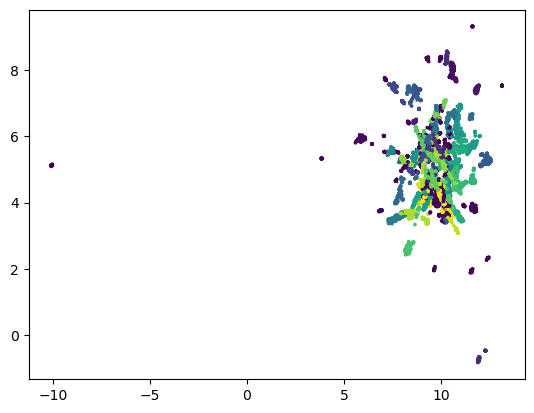

In [39]:
plt.scatter(X_reduced[:, 0], X_reduced[:, 1], c=labels, s=3)

In [40]:
umap_3d = umap.UMAP(n_components=3).fit_transform(X_svd)

In [41]:
import plotly.express as px

In [42]:
fig = px.scatter_3d(
    x=umap_3d[:, 0],
    y=umap_3d[:, 1],
    z=umap_3d[:, 2],
    color=labels,
    opacity=0.7,
    size_max=3
)
fig.show()